In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

In [2]:
file_path = "../data/PPB_Affinity/PPB-Affinity.xlsx"  

print(f"Loading dataset from: {file_path}")

try:
    # 1. Load the Dataset
    df = pd.read_excel(file_path)
    
    # 2. Basic Structural Analysis
    print("\n--- Dataset Structure ---")
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")
    
    # 3. List All Column Names
    print("\n--- Column Names ---")
    print(df.columns.tolist())
    
    # 4. Data Preview
    print("\n--- First 5 Rows ---")
    print(df.head())
    
    # 5. Identification of Key Metrics
    # We search for columns relevant to Affinity (Target) and AI Metrics (Features)
    print("\n--- Relevant Metric Columns Found ---")
    
    keywords = ['kd', 'affinity', 'energy', 'delta', 'plddt', 'ipsae', 'pae', 'tm', 'score', 'rank']
    relevant_cols = [col for col in df.columns if any(key in col.lower() for key in keywords)]
    
    if relevant_cols:
        print(relevant_cols)
        
        # Check for missing values in these critical columns
        print("\n--- Missing Values in Key Metrics ---")
        print(df[relevant_cols].isnull().sum())
    else:
        print("No obvious affinity or AI metric columns found based on keywords.")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Loading dataset from: ../data/PPB_Affinity/PPB-Affinity.xlsx

--- Dataset Structure ---
Rows: 12062
Columns: 19

--- Column Names ---
['Unnamed: 0', 'Source Data Set', 'Complex ID', 'PDB', 'Mutations', 'Ligand Chains', 'Receptor Chains', 'Ligand Name', 'Receptor Name', 'KD(M)', 'Affinity Method', 'Structure Method', 'Temperature(K)', 'Resolution(Å)', 'PDB PubMed ID', 'PDB Release Date', 'Affinity PubMed ID', 'Affinity Release Date', 'Subgroup']

--- First 5 Rows ---
   Unnamed: 0 Source Data Set                  Complex ID   PDB Mutations  \
0           0     SKEMPI v2.0     1A22:A, B::PMID=7504735  1A22       NaN   
1           1     SKEMPI v2.0     1A4Y:A, B::PMID=9050852  1A4Y       NaN   
2           2     SKEMPI v2.0     1ACB:E, I::PMID=9048543  1ACB       NaN   
3           3     SKEMPI v2.0  1AHW:A, B, C::PMID=9480775  1AHW       NaN   
4           4     SKEMPI v2.0     1AK4:A, D::PMID=9223641  1AK4       NaN   

  Ligand Chains Receptor Chains                Ligand Name  \
0   

In [4]:
# Configuration
file_path = "../data/PPB_Affinity/PPB-Affinity-AF.xlsx"

print(f"Loading file: {file_path}")

try:
    df = pd.read_excel(file_path)

    # 1. Dataset Shape
    print("\n--- Dataset Shape ---")
    print(df.shape)

    # 2. All Columns
    print("\n--- Column Names ---")
    print(df.columns.tolist())

    # 3. Data Types
    print("\n--- Data Info ---")
    print(df.info())

    # 4. Search for Key Columns
    print("\n--- Potential Metric Columns ---")
    keywords = ['kd', 'affinity', 'energy', 'delta', 'plddt', 'ipsae', 'pae', 'tm', 'score', 'rank', 'af']
    
    found_cols = [c for c in df.columns if any(k in c.lower() for k in keywords)]
    print(found_cols)

    # 5. Missing Values Check for Found Metrics
    if found_cols:
        print("\n--- Missing Values in Metrics ---")
        print(df[found_cols].isnull().sum())

except Exception as e:
    print(f"Error: {e}")

Loading file: ../data/PPB_Affinity/PPB-Affinity-AF.xlsx

--- Dataset Shape ---
(95, 22)

--- Column Names ---
['Unnamed: 0', 'PDB', 'Source Data Set', 'Model', 'Mutations', 'Ligand Chains', 'Receptor Chains', 'Ligand Name', 'Receptor Name', 'KD(M)', 'Affinity Method', 'Structure Method', 'Temperature(K)', 'Resolution(Å)', 'PDB PubMed ID', 'PDB Release Date', 'Affinity PubMed ID', 'Affinity Release Date', 'Complex ID', 'dG(kcal/mol)', 'Subgroup', 'note']

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             95 non-null     int64         
 1   PDB                    95 non-null     object        
 2   Source Data Set        95 non-null     object        
 3   Model                  0 non-null      float64       
 4   Mutations              25 non-null     object        
 5   Li

In [9]:
pdb_folder_path = "../data/PPB_Affinity/PDB" 

def extract_plddt_from_pdb(file_path):
    """
    Parses a PDB file and calculates the average pLDDT (stored in B-factor col).
    """
    plddt_scores = []
    
    try:
        with open(file_path, 'r') as f:
            for line in f:
                # PDB ATOM records:
                # Columns 61-66 contain the B-factor (pLDDT for AlphaFold)
                if line.startswith("ATOM"):
                    try:
                        # Extract B-factor (pLDDT)
                        b_factor = float(line[60:66].strip())
                        plddt_scores.append(b_factor)
                    except ValueError:
                        continue
                        
        if plddt_scores:
            return np.mean(plddt_scores) # Return Global Average
        else:
            return None
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

# --- MAIN EXECUTION ---
print(f"Scanning folder: {pdb_folder_path}")

data = []

if os.path.exists(pdb_folder_path):
    files = [f for f in os.listdir(pdb_folder_path) if f.endswith('.pdb')]
    print(f"Found {len(files)} PDB files. extracting pLDDT...")
    
    for i, filename in enumerate(files):
        full_path = os.path.join(pdb_folder_path, filename)
        
        # Extract Score
        avg_plddt = extract_plddt_from_pdb(full_path)
        
        # Store Result (filename usually contains the PDB ID)
        if avg_plddt is not None:
            data.append({
                'filename': filename,
                'pdb_id': filename.replace('.pdb', ''), # Removing extension to match IDs
                'extracted_plddt': avg_plddt
            })
            
        # Progress check every 100 files
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1} files...")
            
    # Convert to DataFrame
    df_scores = pd.DataFrame(data)
    print(f"\n✅ Extraction Complete! Extracted scores for {len(df_scores)} files.")
    print(df_scores.head())
    
    # Optional: Save to CSV immediately so you don't lose it
    df_scores.to_csv("extracted_plddt_scores.csv", index=False)
    print("Saved to 'extracted_plddt_scores.csv'")
    
else:
    print("❌ Error: Folder not found. Check your path.")

Scanning folder: ../data/PPB_Affinity/PDB
Found 70 PDB files. extracting pLDDT...

✅ Extraction Complete! Extracted scores for 70 files.
          filename       pdb_id  extracted_plddt
0   HEL-data-1.pdb   HEL-data-1        80.963433
1  HEL-data-10.pdb  HEL-data-10        79.777297
2  HEL-data-11.pdb  HEL-data-11        78.803269
3  HEL-data-12.pdb  HEL-data-12        80.398515
4  HEL-data-13.pdb  HEL-data-13        79.062573
Saved to 'extracted_plddt_scores.csv'


Affinity Data Rows: 95
Scores Data Rows: 70
Merged Rows: 70
Correlation (r): 0.2155


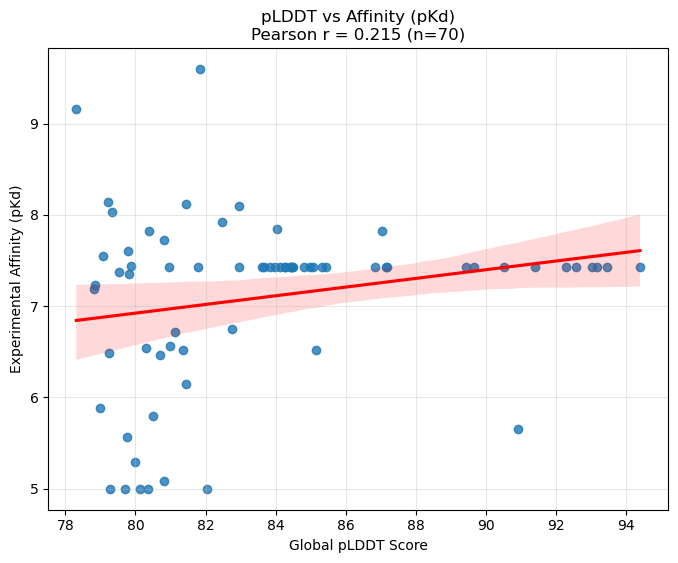

In [13]:
affinity_file = "../data/PPB_Affinity/PPB-Affinity-AF.xlsx"
scores_file = "extracted_plddt_scores.csv"

try:
    df_affinity = pd.read_excel(affinity_file)
    df_scores = pd.read_csv(scores_file)
    
    print("Affinity Data Rows:", len(df_affinity))
    print("Scores Data Rows:", len(df_scores))

    def extract_number(s):
        match = re.search(r'(\d+)', str(s))
        return int(match.group(1)) if match else None

    df_scores['row_index'] = df_scores['pdb_id'].apply(extract_number)
    
    if 'Unnamed: 0' in df_affinity.columns:
        merged = pd.merge(df_affinity, df_scores, left_on='Unnamed: 0', right_on='row_index', how='inner')
    else:
        # Fallback if 'Unnamed: 0' is missing
        df_affinity['row_index'] = df_affinity.index
        merged = pd.merge(df_affinity, df_scores, on='row_index', how='inner')

    print("Merged Rows:", len(merged))

    # 4. Regression Analysis
    if not merged.empty:
        # Prepare Target Variable
        # Check for KD(M) or dG(kcal/mol)
        if 'KD(M)' in merged.columns:
            # Convert KD to pKd (-log10)
            merged['target_val'] = -np.log10(merged['KD(M)'] + 1e-12)
            y_label = "Affinity (pKd)"
        elif 'dG(kcal/mol)' in merged.columns:
            merged['target_val'] = merged['dG(kcal/mol)']
            y_label = "Binding Energy (dG)"
        else:
            merged['target_val'] = None

        if merged['target_val'] is not None:
            # Drop NaN values before calculation
            clean_df = merged.dropna(subset=['target_val', 'extracted_plddt'])

            # Calculate Pearson Correlation
            r = clean_df['target_val'].corr(clean_df['extracted_plddt'])
            p_val = 0.0 # Placeholder, calculating simple correlation first
            
            print(f"Correlation (r): {r:.4f}")

            # Plot Regression
            plt.figure(figsize=(8, 6))
            sns.regplot(data=clean_df, x='extracted_plddt', y='target_val', line_kws={'color':'red'})
            
            plt.title(f"pLDDT vs {y_label}\nPearson r = {r:.3f} (n={len(clean_df)})")
            plt.xlabel("Global pLDDT Score")
            plt.ylabel(f"Experimental {y_label}")
            plt.grid(True, alpha=0.3)
            plt.show()

        else:
            print("Error: No valid affinity column (KD or dG) found.")
    else:
        print("Error: Merge resulted in empty dataframe. Check ID matching.")

except Exception as e:
    print(f"Error executing script: {e}")